# data loading and cleaning

In [151]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [153]:
import pandas as pd
import os

target_file = 'yield.csv'
found_path = None

for root, dirs, files in os.walk("."):
    if target_file in files:
        found_path = root
        break

if found_path:
    print(f"Found files in: {found_path}")
    yield_df = pd.read_csv(os.path.join(found_path, 'yield.csv'))
    temp_df = pd.read_csv(os.path.join(found_path, 'temp.csv'))
    rain_df = pd.read_csv(os.path.join(found_path, 'rainfall.csv'))
    pesticide_df = pd.read_csv(os.path.join(found_path, 'pesticides.csv'))

Found files in: .\OneDrive\เอกสาร\Desktop


In [154]:
temp_df = temp_df.rename(columns={'year': 'Year', 'country': 'Area'})

### merging and data cleaning (integration  of all the 4 csv files for the final_df

In [158]:
for df in [yield_df, temp_df, rain_df, pesticide_df]:
        df.columns = df.columns.str.strip()

In [160]:
merged = pd.merge(yield_df, rain_df, on=['Year', 'Area'])
merged = pd.merge(merged, temp_df, on=['Year', 'Area'])
    
pesticide_df = pesticide_df.rename(columns={'Value': 'pesticides_tonnes'})
final_df = pd.merge(merged, pesticide_df[['Year', 'Area', 'pesticides_tonnes']], on=['Year', 'Area'])


In [162]:
final_df

,Domain Code,Domain,Area Code,Area,Element Code,Element,Item Code,Item,Year Code,Year,Unit,Value,average_rain_fall_mm_per_year,avg_temp,pesticides_tonnes
0,QC,Crops,3,Albania,5419,Yield,56,Maize,1990,1990,hg/ha,36613,1485,16.37,121.00
1,QC,Crops,3,Albania,5419,Yield,56,Maize,1991,1991,hg/ha,29068,1485,15.36,121.00
2,QC,Crops,3,Albania,5419,Yield,56,Maize,1992,1992,hg/ha,24876,1485,16.06,121.00
3,QC,Crops,3,Albania,5419,Yield,56,Maize,1993,1993,hg/ha,24185,1485,16.05,121.00
4,QC,Crops,3,Albania,5419,Yield,56,Maize,1994,1994,hg/ha,25848,1485,16.96,201.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28243,QC,Crops,181,Zimbabwe,5419,Yield,15,Wheat,2009,2009,hg/ha,30000,657,20.52,3269.99
28244,QC,Crops,181,Zimbabwe,5419,Yield,15,Wheat,2010,2010,hg/ha,27681,657,21.17,3305.17
28245,QC,Crops,181,Zimbabwe,5419,Yield,15,Wheat,2011,2011,hg/ha,26274,657,20.78,3340.35
28246,QC,Crops,181,Zimbabwe,5419,Yield,15,Wheat,2012,2012,hg/ha,24420,657,20.52,3375.53


In [164]:
final_df.drop(columns =["Domain Code","Domain","Area Code","Element Code", "Element","Item Code","Year Code","Unit"], inplace = True)

In [166]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28248 entries, 0 to 28247
Data columns (total 7 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Area                           28248 non-null  object 
 1   Item                           28248 non-null  object 
 2   Year                           28248 non-null  int64  
 3   Value                          28248 non-null  int64  
 4   average_rain_fall_mm_per_year  28248 non-null  object 
 5   avg_temp                       28248 non-null  float64
 6   pesticides_tonnes              28248 non-null  float64
dtypes: float64(2), int64(2), object(3)
memory usage: 1.5+ MB


In [168]:
final_df.isnull().sum()

Area                             0
Item                             0
Year                             0
Value                            0
average_rain_fall_mm_per_year    0
avg_temp                         0
pesticides_tonnes                0
dtype: int64

In [170]:
print("\nDuplicate Rows:", final_df.duplicated().sum())


Duplicate Rows: 2310


In [172]:
final_df['avg_temp'] = final_df['avg_temp'].fillna(final_df.groupby('Area')['avg_temp'].transform('mean'))

In [174]:
print("\nDuplicate Rows:", final_df.duplicated().sum())


Duplicate Rows: 2310


In [176]:
final_df.dropna(inplace=True)

In [178]:
final_df

,Area,Item,Year,Value,average_rain_fall_mm_per_year,avg_temp,pesticides_tonnes
0,Albania,Maize,1990,36613,1485,16.37,121.00
1,Albania,Maize,1991,29068,1485,15.36,121.00
2,Albania,Maize,1992,24876,1485,16.06,121.00
3,Albania,Maize,1993,24185,1485,16.05,121.00
4,Albania,Maize,1994,25848,1485,16.96,201.00
...,...,...,...,...,...,...,...
28243,Zimbabwe,Wheat,2009,30000,657,20.52,3269.99
28244,Zimbabwe,Wheat,2010,27681,657,21.17,3305.17
28245,Zimbabwe,Wheat,2011,26274,657,20.78,3340.35
28246,Zimbabwe,Wheat,2012,24420,657,20.52,3375.53


In [180]:
final_df.drop_duplicates(inplace=True)


In [182]:
final_df

,Area,Item,Year,Value,average_rain_fall_mm_per_year,avg_temp,pesticides_tonnes
0,Albania,Maize,1990,36613,1485,16.37,121.00
1,Albania,Maize,1991,29068,1485,15.36,121.00
2,Albania,Maize,1992,24876,1485,16.06,121.00
3,Albania,Maize,1993,24185,1485,16.05,121.00
4,Albania,Maize,1994,25848,1485,16.96,201.00
...,...,...,...,...,...,...,...
28243,Zimbabwe,Wheat,2009,30000,657,20.52,3269.99
28244,Zimbabwe,Wheat,2010,27681,657,21.17,3305.17
28245,Zimbabwe,Wheat,2011,26274,657,20.78,3340.35
28246,Zimbabwe,Wheat,2012,24420,657,20.52,3375.53


In [184]:
final_df['average_rain_fall_mm_per_year'] = pd.to_numeric(final_df['average_rain_fall_mm_per_year'], errors='coerce')

In [186]:
print("NaNs in Rainfall after conversion:", final_df['average_rain_fall_mm_per_year'].isnull().sum())

NaNs in Rainfall after conversion: 6


In [188]:
final_df.dropna(subset=['average_rain_fall_mm_per_year'], inplace=True)

In [190]:
final_df['Area'] = final_df['Area'].str.strip()
final_df['Item'] = final_df['Item'].str.strip()

In [192]:
final_df['yield_tonnes_ha'] = final_df['Value'] * 0.0001  #1 hg/ha = 0.0001 tonnes per hectare

In [194]:
final_df = final_df[(final_df['avg_temp'] > -50) & (final_df['avg_temp'] < 60)]
final_df = final_df[final_df['average_rain_fall_mm_per_year'] >= 0]

print("Sanity check complete. Final shape:", final_df.shape)

Sanity check complete. Final shape: (25932, 8)


In [196]:
final_df['Year'] = final_df['Year'].astype(int)
final_df['Value'] = final_df['Value'].astype(float)

# Reset index after all the dropping/filtering
final_df.reset_index(drop=True, inplace=True)

In [198]:
final_df.index

RangeIndex(start=0, stop=25932, step=1)

In [204]:
final_df

,Area,Item,Year,Value,average_rain_fall_mm_per_year,avg_temp,pesticides_tonnes,yield_tonnes_ha
0,Albania,Maize,1990,36613.0,1485.0,16.37,121.00,3.6613
1,Albania,Maize,1991,29068.0,1485.0,15.36,121.00,2.9068
2,Albania,Maize,1992,24876.0,1485.0,16.06,121.00,2.4876
3,Albania,Maize,1993,24185.0,1485.0,16.05,121.00,2.4185
4,Albania,Maize,1994,25848.0,1485.0,16.96,201.00,2.5848
...,...,...,...,...,...,...,...,...
25927,Zimbabwe,Wheat,2009,30000.0,657.0,20.52,3269.99,3.0000
25928,Zimbabwe,Wheat,2010,27681.0,657.0,21.17,3305.17,2.7681
25929,Zimbabwe,Wheat,2011,26274.0,657.0,20.78,3340.35,2.6274
25930,Zimbabwe,Wheat,2012,24420.0,657.0,20.52,3375.53,2.4420


## corelation heatmap

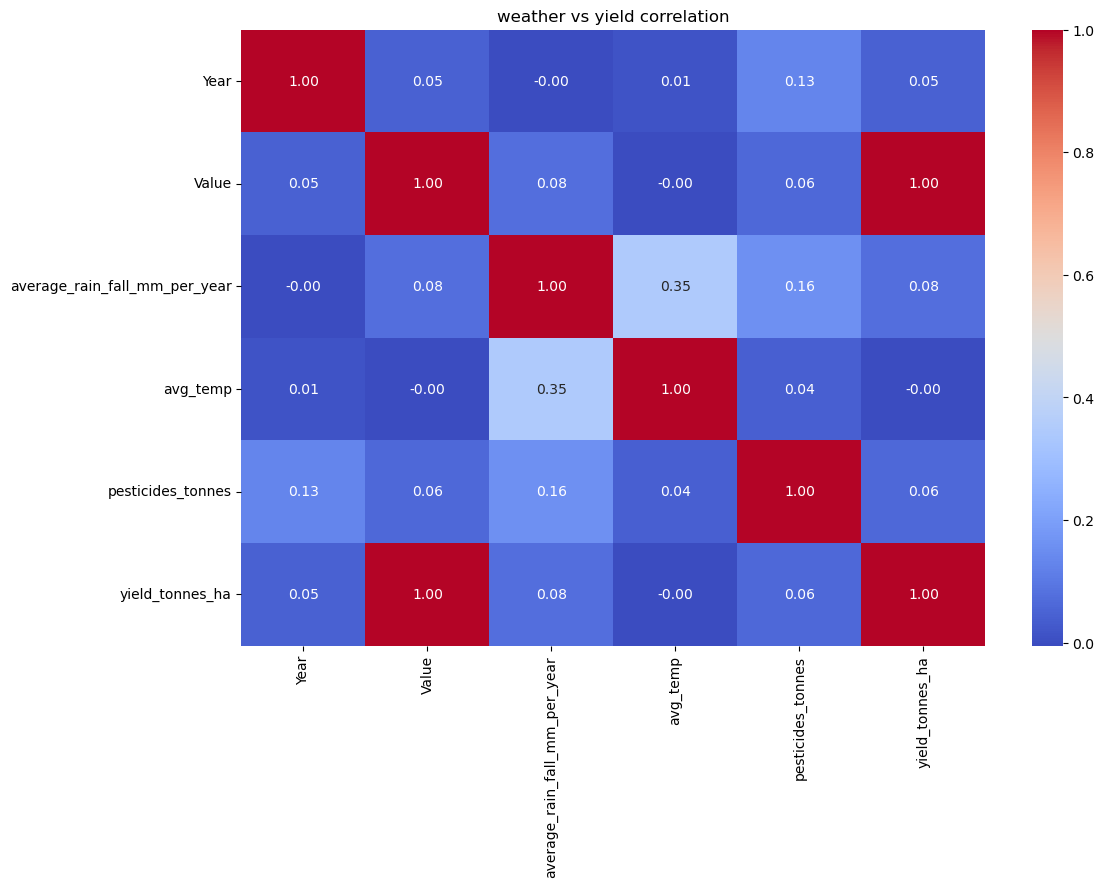

In [213]:
numeric_df = final_df.select_dtypes(include=['float64', 'int64', 'int32'])
plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("weather vs yield correlation")
plt.show()

In [215]:
final_df.columns = [c.replace(' ', '_').replace('(', '').replace(')', '').replace('/', '_') for c in final_df.columns]

In [218]:
final_df

,Area,Item,Year,Value,average_rain_fall_mm_per_year,avg_temp,pesticides_tonnes,yield_tonnes_ha
0,Albania,Maize,1990,36613.0,1485.0,16.37,121.00,3.6613
1,Albania,Maize,1991,29068.0,1485.0,15.36,121.00,2.9068
2,Albania,Maize,1992,24876.0,1485.0,16.06,121.00,2.4876
3,Albania,Maize,1993,24185.0,1485.0,16.05,121.00,2.4185
4,Albania,Maize,1994,25848.0,1485.0,16.96,201.00,2.5848
...,...,...,...,...,...,...,...,...
25927,Zimbabwe,Wheat,2009,30000.0,657.0,20.52,3269.99,3.0000
25928,Zimbabwe,Wheat,2010,27681.0,657.0,21.17,3305.17,2.7681
25929,Zimbabwe,Wheat,2011,26274.0,657.0,20.78,3340.35,2.6274
25930,Zimbabwe,Wheat,2012,24420.0,657.0,20.52,3375.53,2.4420


In [220]:
final_df.to_csv('Crop_Yield_Final_Cleaned.csv', index=False)